# **HW5: Multiple Linear Regression and Logistic Regression**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Regression Models**

In this homework exercise, we will work with two important regression algorithms: **Multiple Linear Regression** (implemented from scratch) for predicting continuous values with multiple features, and **Logistic Regression** (using scikit-learn) for binary classification.

## **Part 1: Multiple Linear Regression**

Multiple linear regression extends simple linear regression to handle **multiple input features**.

**The model equation:**

**y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ**

Or in matrix form:

**y = Xw**

Where:
- **X** is the feature matrix (with a column of 1s for the intercept)
- **w** is the weight vector [b₀, b₁, b₂, ..., bₙ]

**Closed-Form Solution (Normal Equation):**

**w = (XᵀX)⁻¹Xᵀy**

## **Part 2: Logistic Regression**

Despite its name, logistic regression is a **classification** algorithm that models the probability of a binary outcome using the logistic (sigmoid) function.

**The model equation:**

**P(y=1|x) = σ(w·x + b) = 1 / (1 + e^(-(w·x + b)))**

**How it learns:**
- Optimizes parameters using gradient descent
- Minimizes the log loss (cross-entropy loss)
- Outputs probabilities between 0 and 1

We will use scikit-learn's `LogisticRegression` class for this part.

## **Objectives**

In this exercise, you will:
1. Load a dataset with multiple features and implement multiple linear regression
2. Evaluate regression performance using MSE and R² score
3. Use scikit-learn's logistic regression for binary classification
4. Understand false positives and decision thresholds

## **Import Libraries**

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# **PART 1: Multiple Linear Regression**
---

## **Load and Explore the Dataset**

We'll use a synthetic housing dataset to predict house prices based on multiple features.

Features:
- **Square Footage**: Size of the house
- **Number of Bedrooms**: Count of bedrooms
- **Age**: Age of the house in years

Load the data and explore its basic statistics.

In [2]:
# Create synthetic housing dataset
np.random.seed(42)
n_samples = 500

# Generate features
sq_footage = np.random.uniform(800, 3500, n_samples)  # 800 to 3500 sq ft
bedrooms = np.random.randint(1, 6, n_samples)  # 1 to 5 bedrooms
age = np.random.uniform(0, 50, n_samples)  # 0 to 50 years old

# Generate target (price) with some noise
# True relationship: price = 50000 + 100*sqft + 15000*beds - 1000*age + noise
true_intercept = 50000
true_coef_sqft = 100
true_coef_beds = 15000
true_coef_age = -1000

price = (true_intercept + 
         true_coef_sqft * sq_footage + 
         true_coef_beds * bedrooms + 
         true_coef_age * age + 
         np.random.normal(0, 20000, n_samples))  # Add noise

# Create feature matrix
X_housing = np.column_stack([sq_footage, bedrooms, age])
y_housing = price

feature_names = ['Square Footage', 'Bedrooms', 'Age (years)']

print("Housing Dataset Created!")
print("="*60)
print(f"\nDataset shape: {X_housing.shape}")
print(f"Number of samples: {n_samples}")
print(f"Number of features: {len(feature_names)}")

print(f"\nFeature Statistics:")
for i, name in enumerate(feature_names):
    print(f"  {name}: min={X_housing[:, i].min():.1f}, max={X_housing[:, i].max():.1f}, mean={X_housing[:, i].mean():.1f}")

print(f"\nTarget (Price) Statistics:")
print(f"  min=${y_housing.min():,.0f}, max=${y_housing.max():,.0f}, mean=${y_housing.mean():,.0f}")

print(f"\nTrue coefficients:")
print(f"  Intercept: ${true_intercept:,}")
print(f"  Square Footage: ${true_coef_sqft}/sqft")
print(f"  Bedrooms: ${true_coef_beds:,}/bedroom")
print(f"  Age: ${true_coef_age:,}/year")

Housing Dataset Created!

Dataset shape: (500, 3)
Number of samples: 500
Number of features: 3

Feature Statistics:
  Square Footage: min=813.7, max=3481.0, mean=2146.1
  Bedrooms: min=1.0, max=5.0, mean=3.0
  Age (years): min=0.0, max=50.0, mean=25.4

Target (Price) Statistics:
  min=$103,883, max=$452,511, mean=$282,982

True coefficients:
  Intercept: $50,000
  Square Footage: $100/sqft
  Bedrooms: $15,000/bedroom
  Age: $-1,000/year


## **Visualize the Data**

Create scatter plots showing the relationship between each feature and the target (price).

This will help you understand how each feature relates to the house price.

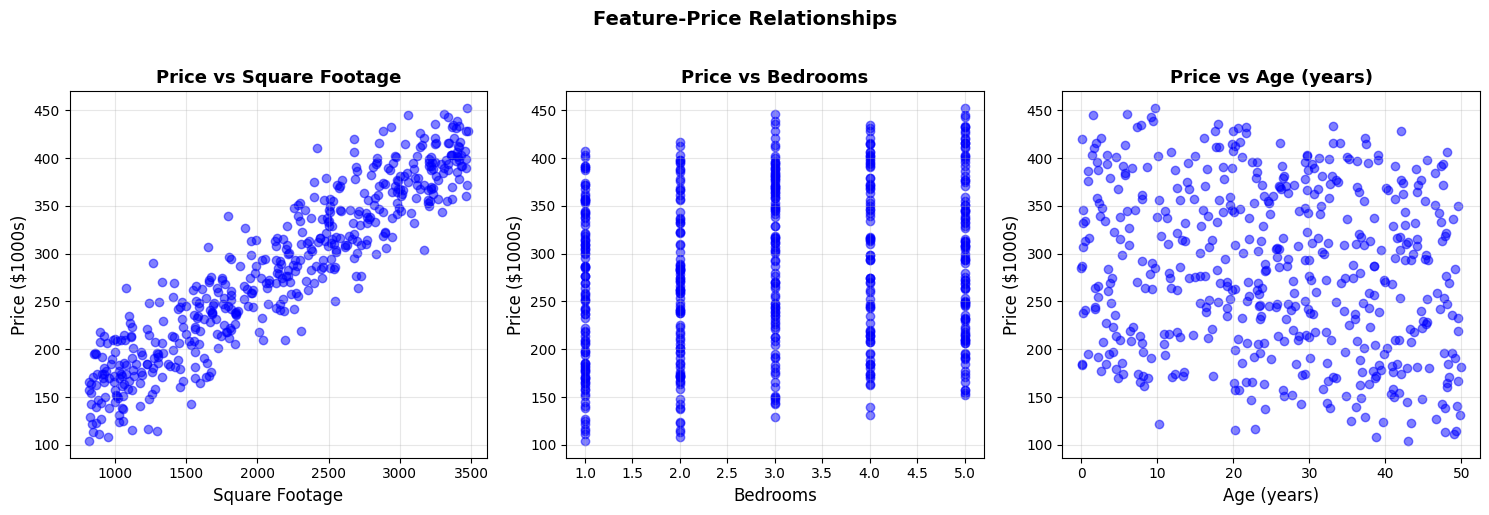

Observations:
- Square Footage shows a positive linear relationship with price
- Bedrooms shows a positive relationship (more rooms = higher price)
- Age shows a negative relationship (older houses = lower price)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.scatter(X_housing[:, i], y_housing/1000, alpha=0.5, c='blue')
    ax.set_xlabel(name, fontsize=12)
    ax.set_ylabel('Price ($1000s)', fontsize=12)
    ax.set_title(f'Price vs {name}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature-Price Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observations:")
print("- Square Footage shows a positive linear relationship with price")
print("- Bedrooms shows a positive relationship (more rooms = higher price)")
print("- Age shows a negative relationship (older houses = lower price)")

## **TASK 1: Split the Data**

Split the dataset into training (75%) and testing (25%) sets using the `train_test_split` function from scikit-learn.

**Note:** For multiple linear regression, we don't need to standardize features when using the normal equation, but we will for comparison with gradient descent methods later.

In [4]:
# Write your code here

# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_housing, y_housing, test_size=0.25, random_state=42)

print("Data split successfully!")
print(f"Training set: {X_train_h.shape[0]} samples")
print(f"Testing set:  {X_test_h.shape[0]} samples")

Data split successfully!
Training set: 375 samples
Testing set:  125 samples


## **TASK 2: Implement Multiple Linear Regression**

Implement the `multiple_linear_regression()` function using the **Normal Equation**:

**w = (XᵀX)⁻¹Xᵀy**

Your function should:
1. Add a column of 1s to X for the intercept term
2. Compute the weights using the normal equation
3. Return the weight vector

**Hints:**
- Use `np.column_stack()` or `np.hstack()` to add the intercept column
- Use `np.linalg.inv()` for matrix inverse
- Use `@` or `np.dot()` for matrix multiplication

In [15]:
def multiple_linear_regression(X, y):
    """
    Perform multiple linear regression using the normal equation.
    
    Parameters:
    -----------
    X : numpy array
        Feature matrix (m samples x n features)
    y : numpy array
        Target values (m samples)
    
    Returns:
    --------
    weights : numpy array
        Learned weights including intercept (n+1 values)
    """
    x = np.column_stack([np.ones(X.shape[0]), X])
    weights = np.linalg.pinv(x.T @ x) @ (x.T @ y)
    return weights


def predict_mlr(X, weights):
    """
    Make predictions using learned weights.
    
    Parameters:
    -----------
    X : numpy array
        Feature matrix (m samples x n features)
    weights : numpy array
        Learned weights including intercept
    
    Returns:
    --------
    predictions : numpy array
        Predicted values
    """
    x = np.column_stack([np.ones(X.shape[0]), X])
    predictions = x @ weights
    return predictions


print("Multiple linear regression functions defined successfully!")

Multiple linear regression functions defined successfully!


## **Train and Evaluate the Model**

Train your multiple linear regression model and evaluate its performance:

1. Train the model on the training set
2. Print the learned weights and compare with true coefficients
3. Calculate predictions on both training and test sets
4. Compute MSE and R² score for both sets

**R² Score Formula:**

**R² = 1 - (SS_res / SS_tot)**

Where:
- SS_res = Σ(y - ŷ)² (residual sum of squares)
- SS_tot = Σ(y - ȳ)² (total sum of squares)

In [6]:
# Train the model
weights = multiple_linear_regression(X_train_h, y_train_h)

print("Multiple Linear Regression Results:")
print("="*60)
print(f"\nLearned weights:")
print(f"  Intercept:       ${weights[0]:,.2f}")
print(f"  Square Footage:  ${weights[1]:.2f}/sqft")
print(f"  Bedrooms:        ${weights[2]:,.2f}/bedroom")
print(f"  Age:             ${weights[3]:.2f}/year")

print(f"\nTrue coefficients (for comparison):")
print(f"  Intercept:       ${true_intercept:,}")
print(f"  Square Footage:  ${true_coef_sqft}/sqft")
print(f"  Bedrooms:        ${true_coef_beds:,}/bedroom")
print(f"  Age:             ${true_coef_age}/year")

# Make predictions
y_train_pred_h = predict_mlr(X_train_h, weights)
y_test_pred_h = predict_mlr(X_test_h, weights)

# Calculate MSE
mse_train = np.mean((y_train_h - y_train_pred_h) ** 2)
mse_test = np.mean((y_test_h - y_test_pred_h) ** 2)

# Calculate R² score
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_train = r2_score(y_train_h, y_train_pred_h)
r2_test = r2_score(y_test_h, y_test_pred_h)

print(f"\nModel Performance:")
print(f"  Training MSE: ${mse_train:,.0f}")
print(f"  Test MSE:     ${mse_test:,.0f}")
print(f"  Training R²:  {r2_train:.4f}")
print(f"  Test R²:      {r2_test:.4f}")

print(f"\nInterpretation:")
print(f"  R² = {r2_test:.4f} means {r2_test*100:.1f}% of variance is explained by the model")

Multiple Linear Regression Results:

Learned weights:
  Intercept:       $50,768.02
  Square Footage:  $100.36/sqft
  Bedrooms:        $13,974.93/bedroom
  Age:             $-978.06/year

True coefficients (for comparison):
  Intercept:       $50,000
  Square Footage:  $100/sqft
  Bedrooms:        $15,000/bedroom
  Age:             $-1000/year

Model Performance:
  Training MSE: $403,572,383
  Test MSE:     $445,360,222
  Training R²:  0.9468
  Test R²:      0.9322

Interpretation:
  R² = 0.9322 means 93.2% of variance is explained by the model


## **TASK 3: Visualize Predictions**

Create a scatter plot comparing predicted prices vs actual prices on the test set.

A perfect model would have all points on the diagonal line (y = x).

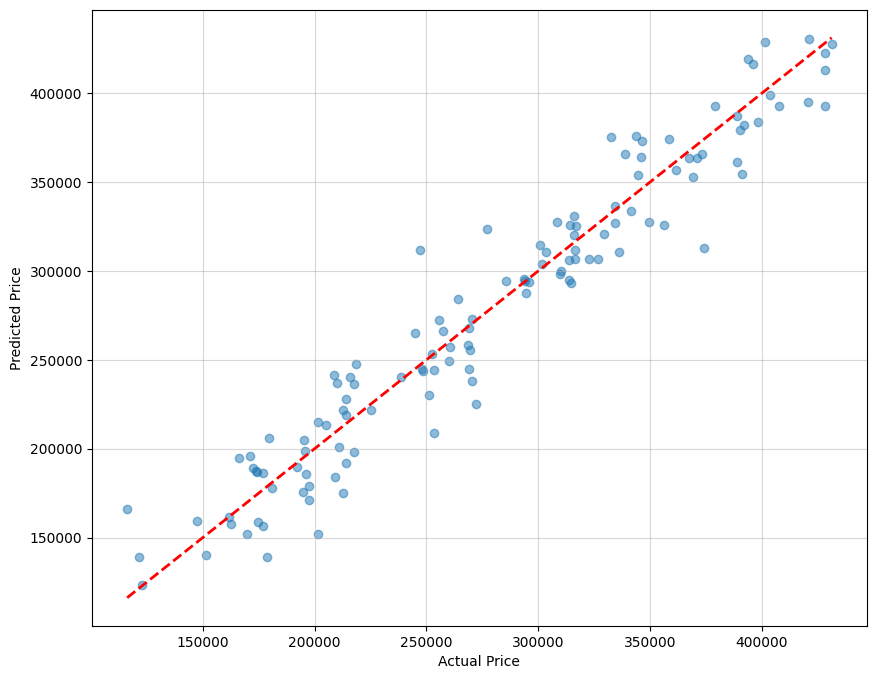

Points close to the red line indicate accurate predictions.
Points above the line: model overestimated
Points below the line: model underestimated


In [16]:
# Write your code here

plt.figure(figsize=(10, 8))

plt.scatter(y_test_h, y_test_pred_h, alpha=0.5)

min = min(y_test_h.min(), y_test_pred_h.min())
max = max(y_test_h.max(), y_test_pred_h.max())
plt.plot([min, max], [min, max], 'r--', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True, alpha=0.5)

plt.show()

print("Points close to the red line indicate accurate predictions.")
print("Points above the line: model overestimated")
print("Points below the line: model underestimated")

---
# **PART 2: Logistic Regression**
---

## **Understanding Logistic Regression**

Logistic regression is a classification algorithm that models the probability of a binary outcome using the logistic (sigmoid) function.

**The model equation:**

**P(y=1|x) = σ(w·x + b) = 1 / (1 + e^(-(w·x + b)))**

**How it learns:**
- Optimizes parameters (w and b) to maximize the likelihood of the training data
- Uses gradient descent to minimize the log loss (cross-entropy loss)
- Outputs probabilities between 0 and 1

## **Understanding False Positives**

In binary classification, we have four possible outcomes:
- **True Positive (TP)**: Correctly predicted positive class
- **True Negative (TN)**: Correctly predicted negative class
- **False Positive (FP)**: Incorrectly predicted positive when actual is negative (Type I error)
- **False Negative (FN)**: Incorrectly predicted negative when actual is positive (Type II error)

**False Positive** occurs when the model predicts a positive outcome, but the actual outcome is negative.

## **Load Classification Dataset**

Load the Breast Cancer Wisconsin dataset for logistic regression. This is a binary classification dataset where the goal is to predict whether a tumor is malignant or benign.

Split and standardize the data as before.

In [11]:
# Load the dataset
data = load_breast_cancer()
X_cancer, y_cancer = data.data, data.target

print("Breast Cancer Dataset loaded!")
print("="*60)
print(f"\nDataset shape: {X_cancer.shape}")
print(f"Number of features: {X_cancer.shape[1]}")

print(f"\nClass distribution:")
unique, counts = np.unique(y_cancer, return_counts=True)
for label, count in zip(unique, counts):
    class_name = data.target_names[label]
    print(f"  Class {label} ({class_name}): {count} samples ({count/len(y_cancer)*100:.1f}%)")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nData split and standardized!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Breast Cancer Dataset loaded!

Dataset shape: (569, 30)
Number of features: 30

Class distribution:
  Class 0 (malignant): 212 samples (37.3%)
  Class 1 (benign): 357 samples (62.7%)

Data split and standardized!
Training set: 426 samples
Testing set:  143 samples


## **TASK 4: Train Logistic Regression with Scikit-Learn**

Use scikit-learn's `LogisticRegression` class to train a logistic regression model:

1. Create a `LogisticRegression` model with `random_state=42` and `max_iter=1000`
2. Fit the model on the training data
3. Make predictions on both training and test sets
4. Calculate and print the training and test accuracy

Scikit-learn API: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [12]:
print("Training Logistic Regression with Scikit-Learn...")
print("="*60)

# Create and train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Training complete!")
print(f"\nModel parameters:")
print(f"  Coefficients shape: {model.coef_.shape}")
print(f"  Intercept: {model.intercept_[0]:.6f}")

# Make predictions on training set
y_train_pred_lr = model.predict(X_train)
train_accuracy_lr = np.mean(y_train_pred_lr == y_train)

# Make predictions on test set
y_test_pred_lr = model.predict(X_test)
test_accuracy_lr = np.mean(y_test_pred_lr == y_test)

print(f"\nLogistic Regression Performance:")
print(f"  Training Accuracy: {train_accuracy_lr:.4f} ({train_accuracy_lr*100:.2f}%)")
print(f"  Test Accuracy:     {test_accuracy_lr:.4f} ({test_accuracy_lr*100:.2f}%)")
print(f"\nDifference: {(train_accuracy_lr - test_accuracy_lr)*100:.2f}%")

Training Logistic Regression with Scikit-Learn...
Training complete!

Model parameters:
  Coefficients shape: (1, 30)
  Intercept: 0.280555

Logistic Regression Performance:
  Training Accuracy: 0.9883 (98.83%)
  Test Accuracy:     0.9860 (98.60%)

Difference: 0.22%


## **TASK 5: Understanding and Analyzing False Positives**

In this task, you'll explore the concept of **false positives** and learn how to control them by adjusting the decision threshold.

**In our breast cancer dataset:**
- Class 1 = benign (non-cancerous) - this is our "positive" class
- Class 0 = malignant (cancerous) - this is our "negative" class
- **False Positive** = predicting a tumor is benign when it's actually malignant

**Your tasks:**

1. Implement a function `count_false_positives(y_true, y_pred)` that counts the number of false positives
2. Calculate the number of false positives in your test set predictions (with threshold=0.5)
3. **Find a threshold that gives fewer than 3 false positives on the test set**

In [13]:
# Write your code here

def count_false_positives(y_true, y_pred):
    """
    Count the number of false positives.
    
    False Positive: Predicted positive (1) but actually negative (0)
    
    Parameters:
    -----------
    y_true : numpy array
        True labels
    y_pred : numpy array
        Predicted labels
    
    Returns:
    --------
    int
        Number of false positives
    """
    # False positive: predicted 1, actual 0
    return int(np.sum((y_pred == 1) & (y_true == 0)))


# Count false positives with default threshold (0.5)
fp_default = count_false_positives(y_test, y_test_pred_lr)

print("False Positive Analysis")
print("="*60)
print(f"\nWith default threshold (0.5):")
print(f"  False Positives: {fp_default}")
print(f"  This means {fp_default} malignant tumors were incorrectly classified as benign.")

# Calculate confusion matrix components
true_positives = np.sum((y_test_pred_lr == 1) & (y_test == 1))
true_negatives = np.sum((y_test_pred_lr == 0) & (y_test == 0))
false_negatives = np.sum((y_test_pred_lr == 0) & (y_test == 1))

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Positives:   {true_positives} (correctly predicted benign)")
print(f"  True Negatives:   {true_negatives} (correctly predicted malignant)")
print(f"  False Positives:  {fp_default} (malignant predicted as benign)")
print(f"  False Negatives:  {false_negatives} (benign predicted as malignant)")

print("\n" + "="*60)
print("Finding threshold with fewer than 3 false positives...")
print("="*60)

# Get probability predictions using sklearn's predict_proba
# predict_proba returns probabilities for both classes: [:, 0] for class 0, [:, 1] for class 1
y_test_proba = model.predict_proba(X_test)[:, 1]  # Get probability for class 1 (benign)

# Try different thresholds
thresholds = np.arange(0.5, 0.96, 0.01)
results = []

for threshold in thresholds:
    y_pred_thresh = (y_test_proba >= threshold).astype(int)
    fp = count_false_positives(y_test, y_pred_thresh)
    accuracy = np.mean(y_pred_thresh == y_test)
    results.append((threshold, fp, accuracy))

# Find thresholds with fewer than 3 false positives
valid_thresholds = [(t, fp, acc) for t, fp, acc in results if fp < 3]

if valid_thresholds:
    # Get the threshold with highest accuracy among valid ones
    best_threshold, best_fp, best_accuracy = max(valid_thresholds, key=lambda x: x[2])
    
    print(f"\nFound {len(valid_thresholds)} thresholds with fewer than 3 false positives!")
    print(f"\nBest threshold: {best_threshold:.2f}")
    print(f"  False Positives: {best_fp}")
    print(f"  Test Accuracy:   {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    
    print(f"\nAll valid thresholds (first 5):")
    for t, fp, acc in valid_thresholds[:5]:
        print(f"  Threshold {t:.2f}: FP={fp}, Accuracy={acc:.4f}")
else:
    print("No threshold found with fewer than 3 false positives.")
    print("This suggests the model needs improvement or the constraint is too strict.")

False Positive Analysis

With default threshold (0.5):
  False Positives: 1
  This means 1 malignant tumors were incorrectly classified as benign.

Confusion Matrix Breakdown:
  True Positives:   89 (correctly predicted benign)
  True Negatives:   52 (correctly predicted malignant)
  False Positives:  1 (malignant predicted as benign)
  False Negatives:  1 (benign predicted as malignant)

Finding threshold with fewer than 3 false positives...

Found 46 thresholds with fewer than 3 false positives!

Best threshold: 0.50
  False Positives: 1
  Test Accuracy:   0.9860 (98.60%)

All valid thresholds (first 5):
  Threshold 0.50: FP=1, Accuracy=0.9860
  Threshold 0.51: FP=1, Accuracy=0.9860
  Threshold 0.52: FP=1, Accuracy=0.9860
  Threshold 0.53: FP=1, Accuracy=0.9860
  Threshold 0.54: FP=1, Accuracy=0.9860


## **Visualize Threshold Impact**

Create a visualization showing how the number of false positives changes with different thresholds.

Plot:
1. False positives vs threshold (left y-axis)
2. Accuracy vs threshold (right y-axis)
3. Add a horizontal line at 3 false positives
4. Mark the best threshold you found

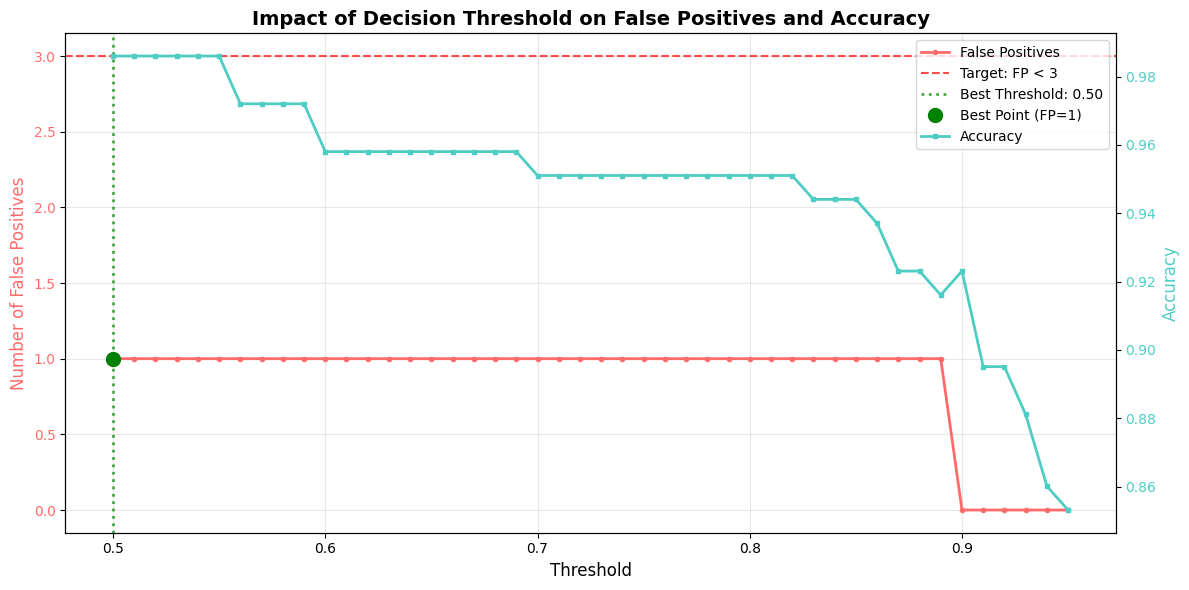


Key Observations:
1. As threshold increases, false positives decrease (model becomes more conservative)
2. However, accuracy may also decrease as we become too conservative
3. The goal is to find the sweet spot: minimize FPs while maintaining good accuracy
4. In medical applications, reducing false positives is critical (don't miss cancer cases!)


In [14]:
# Write your code here

# Extract data for plotting
thresholds_plot = [r[0] for r in results]
fp_plot = [r[1] for r in results]
acc_plot = [r[2] for r in results]

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot false positives on left axis
color = '#FF6B6B'
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Number of False Positives', color=color, fontsize=12)
line1 = ax1.plot(thresholds_plot, fp_plot, color=color, linewidth=2, label='False Positives', marker='o', markersize=3)
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=3, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target: FP < 3')
ax1.grid(True, alpha=0.3)

# Create second y-axis for accuracy
ax2 = ax1.twinx()
color = '#4ECDC4'
ax2.set_ylabel('Accuracy', color=color, fontsize=12)
line2 = ax2.plot(thresholds_plot, acc_plot, color=color, linewidth=2, label='Accuracy', marker='s', markersize=3)
ax2.tick_params(axis='y', labelcolor=color)

# Mark the best threshold
if valid_thresholds:
    best_idx = thresholds_plot.index(best_threshold)
    ax1.axvline(x=best_threshold, color='green', linestyle=':', linewidth=2, alpha=0.7, label=f'Best Threshold: {best_threshold:.2f}')
    ax1.plot(best_threshold, fp_plot[best_idx], 'go', markersize=10, label=f'Best Point (FP={best_fp})')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title('Impact of Decision Threshold on False Positives and Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. As threshold increases, false positives decrease (model becomes more conservative)")
print("2. However, accuracy may also decrease as we become too conservative")
print("3. The goal is to find the sweet spot: minimize FPs while maintaining good accuracy")
print("4. In medical applications, reducing false positives is critical (don't miss cancer cases!)")

## **TASK 6: Reflection Questions**

Answer the following questions based on your implementation and results:

1. **Multiple vs Simple Linear Regression**: What is the main difference between simple and multiple linear regression? When would you use one over the other?

2. **R² Interpretation**: What does an R² score of 0.85 mean? What would R² = 1 and R² = 0 indicate?

3. **Logistic vs Linear Regression**: Why can't we use linear regression for classification tasks? What makes logistic regression suitable for binary classification?

4. **False Positives**: In the breast cancer detection context, why is minimizing false positives critical? What would be the consequence?

5. **Threshold Trade-off**: When you adjusted the threshold to reduce false positives, what happened to the overall accuracy? Is this trade-off acceptable in medical applications?

**Write your answers in the markdown cell below.**

## **Your Answers:**

**1. Multiple vs Simple Linear Regression:**

Multiple regression uses two or more features where simple regression only uses one feature. You use multiple regression when there are multiple variables that influence the outcome

**2. R² Interpretation:**

An R^2 of 0.85 means that the model explains 85% of the variation in the variable. R^2 = 1 means that it is a perfect fit and R^2 = 0 means the model explains none of the variation.

**3. Logistic vs Linear Regression:**

We can't use linear regression for classification tasks because it ouputs any real number. In logistic regression the outputs are between 0 and 1

**4. False Positives:**

Minimizing false positives reduces unnecessary re-tests, costs, and stress for the patients

**5. Threshold Trade-off:**

Raising the threshold can reduce false positives but it can also increase false negative and overall lower the accuracy. 

---
## **Summary and Key Takeaways**

### Part 1: Multiple Linear Regression

1. **Multiple Linear Regression** extends simple regression to multiple features
2. Uses the equation: **y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ**
3. Solved using the **Normal Equation**: **w = (XᵀX)⁻¹Xᵀy**
4. **R² score** measures how well the model explains variance (0 to 1)
5. Coefficients are interpretable (effect of each feature on target)

### Part 2: Logistic Regression

1. **Logistic Regression** is for binary classification despite its name
2. Uses sigmoid function to output probabilities between 0 and 1
3. Scikit-learn's `LogisticRegression` handles training automatically
4. **Decision threshold** controls the trade-off between different error types
5. **False positives** can be controlled by adjusting the threshold
6. Use `predict_proba()` to get probability outputs for threshold tuning

### Key Differences

| Aspect | Multiple Linear Regression | Logistic Regression |
|--------|---------------------------|--------------------|
| Output | Continuous values | Probabilities (0-1) |
| Task | Regression | Classification |
| Loss | MSE | Cross-entropy |
| Solution | Normal equation | Gradient descent |

### Real-World Applications

- **Multiple Linear Regression**: House price prediction, sales forecasting, economic modeling
- **Logistic Regression**: Medical diagnosis, spam detection, credit risk assessment

### Congratulations!

You've successfully implemented multiple linear regression from scratch and used scikit-learn's logistic regression for classification, understanding their mathematical foundations and practical applications!